In [1]:
import  os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, cross_val_predict

from sklearn.linear_model import LogisticRegression

# 1. Load Data

In [2]:
data = datasets.load_iris()

In [3]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
data['data'][:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [5]:
data['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [6]:
data['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [7]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

We are trying to use attributes of flowers to predict the species of the flower. Specifically we are trying to use the sepal length and width and the petal length and width to predict if an Iris Flower is of type ***Setosa***, ***Versicolor***, or ***Virginica***

In [8]:
df = pd.DataFrame(data["data"], columns = data['feature_names'])

In [9]:
df['target'] = data['target']

In [10]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# 2. Data Analysis

In [11]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


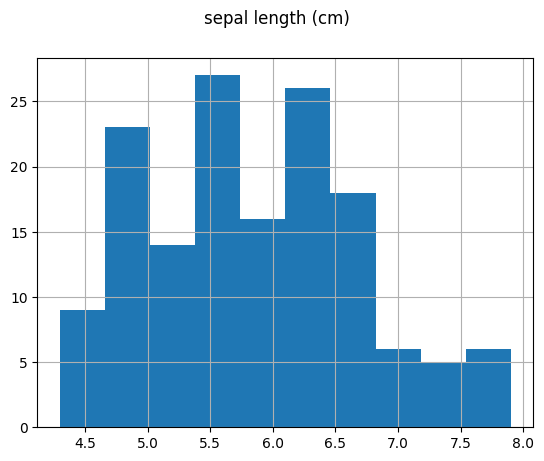

In [12]:
col = "sepal length (cm)"
df[col].hist()
plt.suptitle(col)
plt.show()

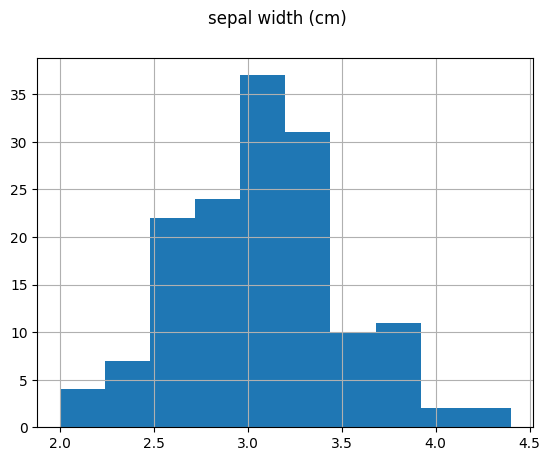

In [13]:
col = "sepal width (cm)"
df[col].hist()
plt.suptitle(col)
plt.show()

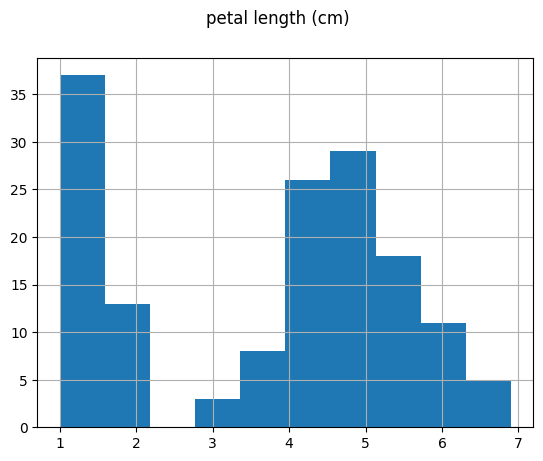

In [14]:
col = "petal length (cm)"
df[col].hist()
plt.suptitle(col)
plt.show()

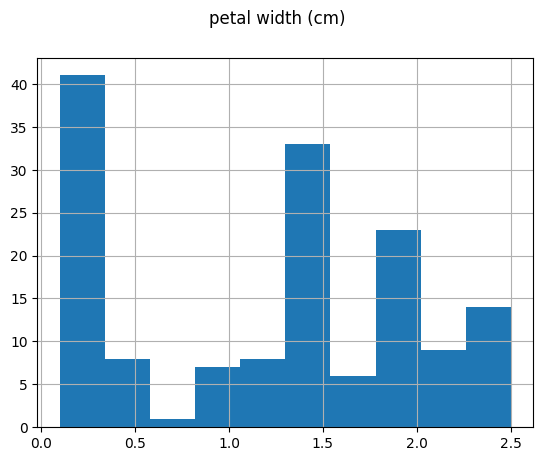

In [15]:
col = "petal width (cm)"
df[col].hist()
plt.suptitle(col)
plt.show()

# 3. Relationship of data features

In [16]:
data["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [17]:
df["target_name"] = df["target"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

In [18]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


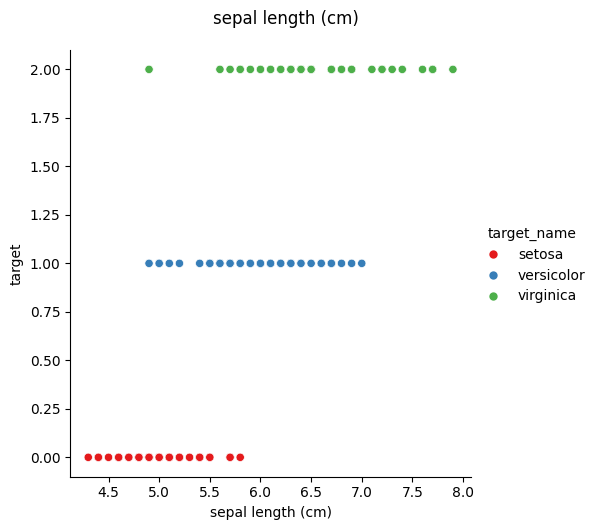

In [19]:
col = "sepal length (cm)"
sns.relplot(x = col, y = 'target', hue='target_name', palette = 'Set1', data =df)
plt.suptitle(col, y =1.05)
plt.show()

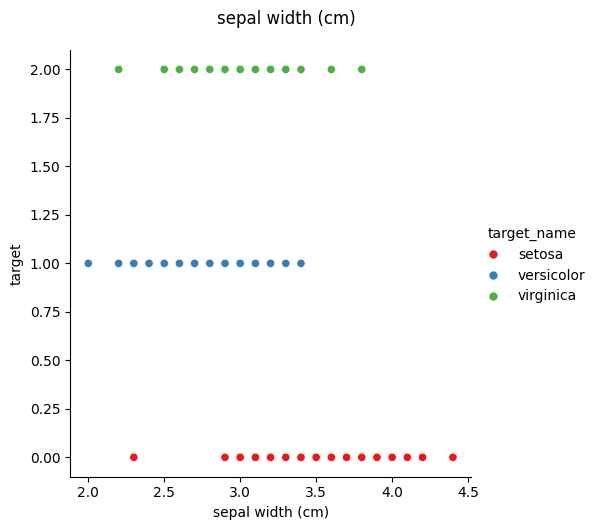

In [20]:
col = "sepal width (cm)"
sns.relplot(x = col, y = 'target', hue='target_name', palette = 'Set1', data =df)
plt.suptitle(col, y =1.05)
plt.show()

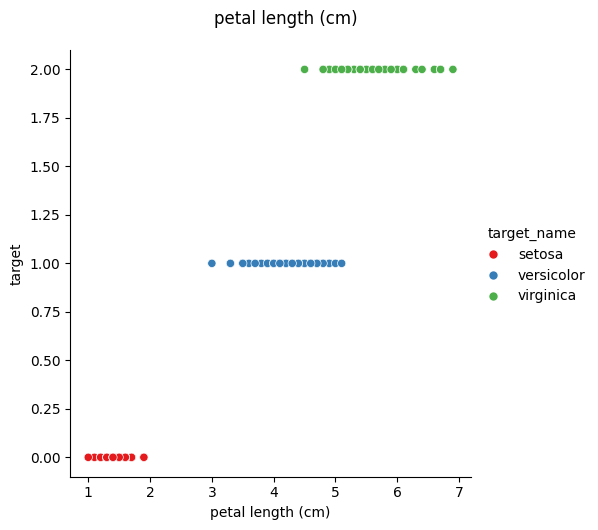

In [21]:
col = "petal length (cm)"
sns.relplot(x = col, y = 'target', hue='target_name', palette = 'Set1', data =df)
plt.suptitle(col, y =1.05)
plt.show()

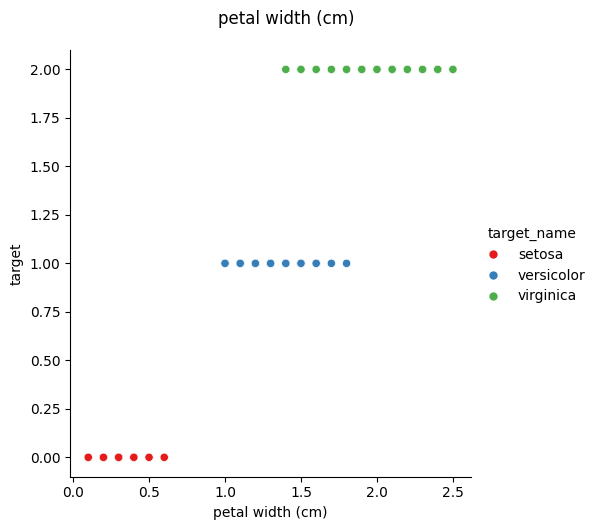

In [22]:
col = "petal width (cm)"
sns.relplot(x = col, y = 'target', hue='target_name', palette = 'Set1', data =df)
plt.suptitle(col, y =1.05)
plt.show()

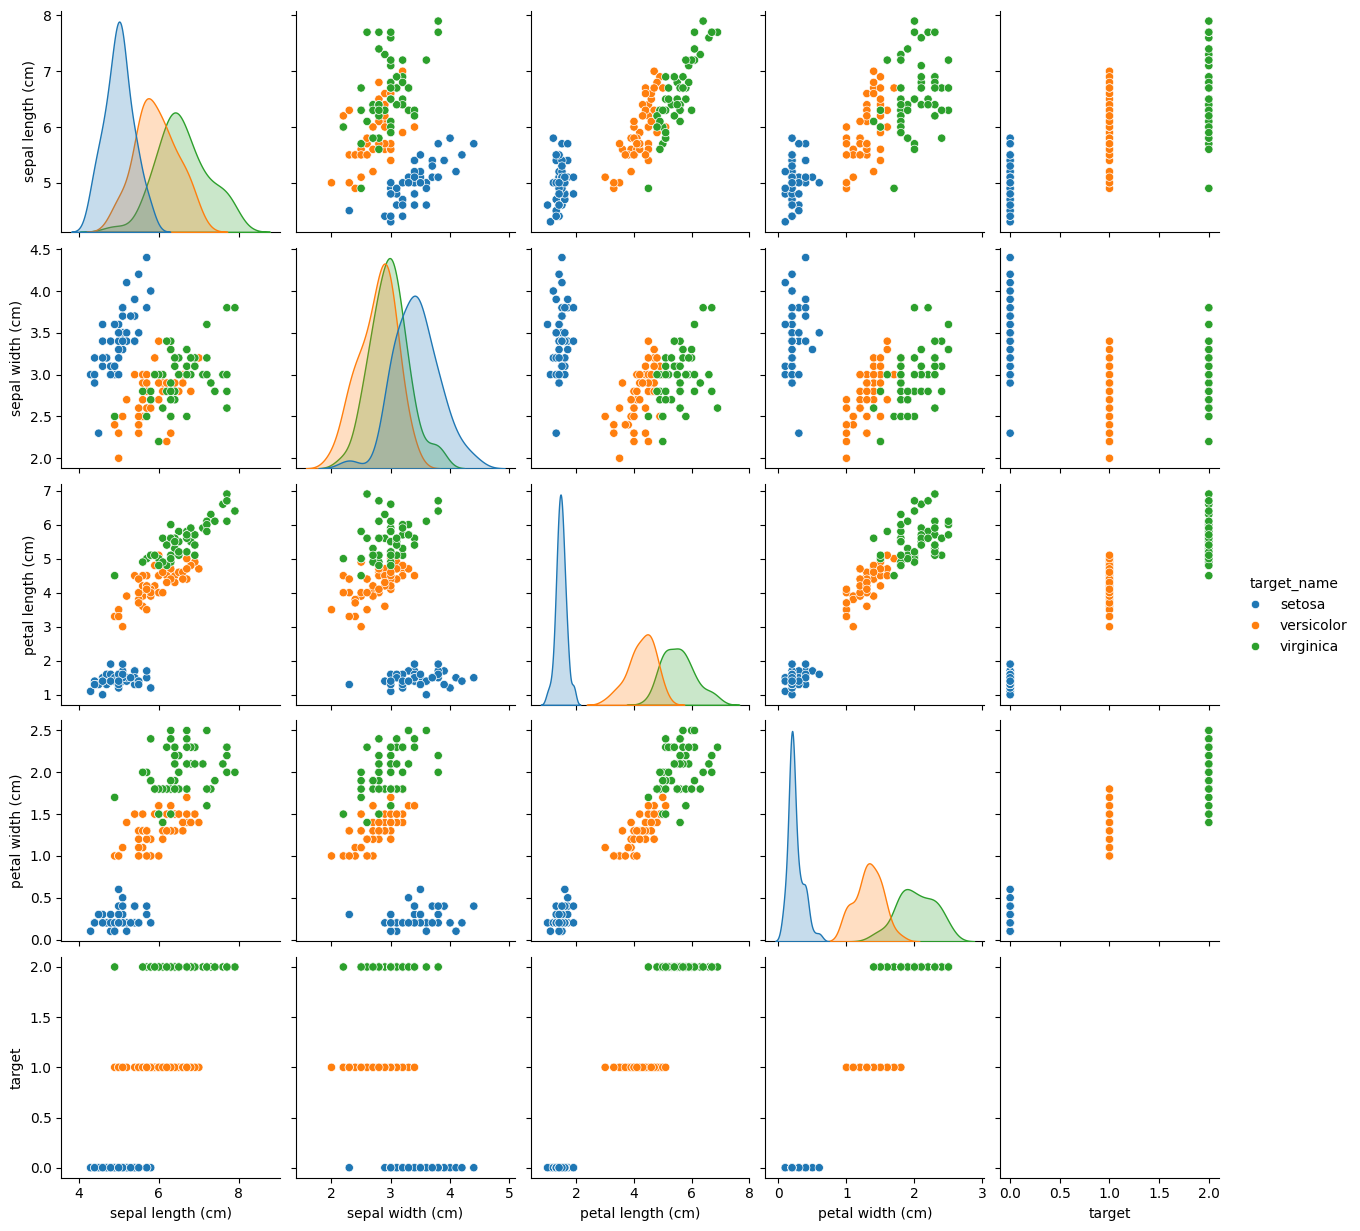

In [23]:
sns.pairplot(df, hue = "target_name")

# 4. Train Test

In [24]:
df_train, df_test = train_test_split(df, test_size = 0.25)

In [25]:
df_train.shape

(112, 6)

In [26]:
df_test.shape

(38, 6)

In [27]:
X_train = df_train.drop(columns=['target', 'target_name']).values
print(X_train.shape)
y_train = df_train['target'].values
y_train

(112, 4)


array([2, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 0,
       2, 1, 2, 2, 2, 1, 0, 1, 0, 0, 0, 0, 1, 2, 2, 1, 2, 0, 0, 0, 2, 1,
       1, 1, 1, 1, 2, 2, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 1, 0, 1, 1, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 2, 1, 0,
       1, 0, 2, 2, 2, 1, 0, 2, 2, 2, 1, 0, 1, 2, 0, 1, 1, 2, 1, 2, 2, 2,
       1, 2])

In [28]:
X_test = df_test.drop(columns=['target', 'target_name']).values
print(X_test.shape)
y_test = df_test['target'].values
y_test

(38, 4)


array([0, 0, 1, 2, 1, 2, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 2, 1, 1, 1, 0,
       2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 1, 2, 2, 0, 2])

In [29]:
# Model : Logistic Regression
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
model.score(X_test, y_test)

1.0

In [31]:
accuracies = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
np.mean(accuracies)

0.9644268774703557

In [32]:
y_pred = cross_val_predict(model, X_train, y_train, cv=5)

In [33]:
predicted_correctly_mask = y_pred == y_train

In [34]:
not_predicted_correctly_mask = ~predicted_correctly_mask

In [35]:
X_train[not_predicted_correctly_mask]

array([[6. , 2.7, 5.1, 1.6],
       [5.9, 3.2, 4.8, 1.8],
       [6.7, 3. , 5. , 1.7],
       [4.9, 2.5, 4.5, 1.7]])

In [36]:
df_predictions = df_train.copy()

In [37]:
df_predictions["correct_prediction"] = predicted_correctly_mask

In [38]:
df_predictions["prediction"] = y_pred

In [39]:
df_predictions["prediction_label"] = df_predictions["prediction"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

In [40]:
df_predictions.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name,correct_prediction,prediction,prediction_label
107,7.3,2.9,6.3,1.8,2,virginica,True,2,virginica
86,6.7,3.1,4.7,1.5,1,versicolor,True,1,versicolor
29,4.7,3.2,1.6,0.2,0,setosa,True,0,setosa
55,5.7,2.8,4.5,1.3,1,versicolor,True,1,versicolor
11,4.8,3.4,1.6,0.2,0,setosa,True,0,setosa


<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

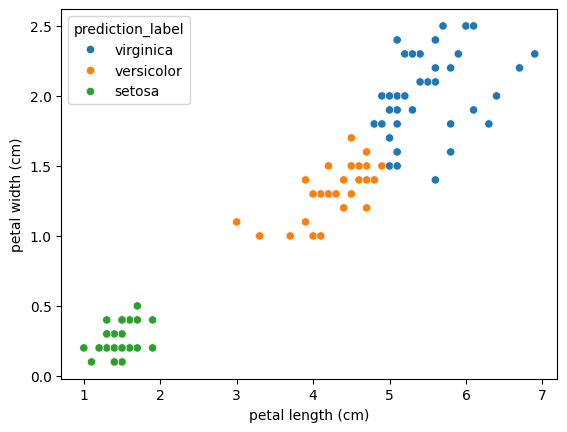

In [41]:
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue = 'prediction_label', data=df_predictions)

In [42]:
def plot_incorrect_predictions(df_predictions, x_axis_feature, y_axis_feature):
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    axs = axs.flatten()
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue="prediction_label", data=df_predictions, ax=axs[0])
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue="target_name", data=df_predictions, ax=axs[1])
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue="correct_prediction", data=df_predictions, ax=axs[2])
    axs[3].set_visible(False)

plt.show()

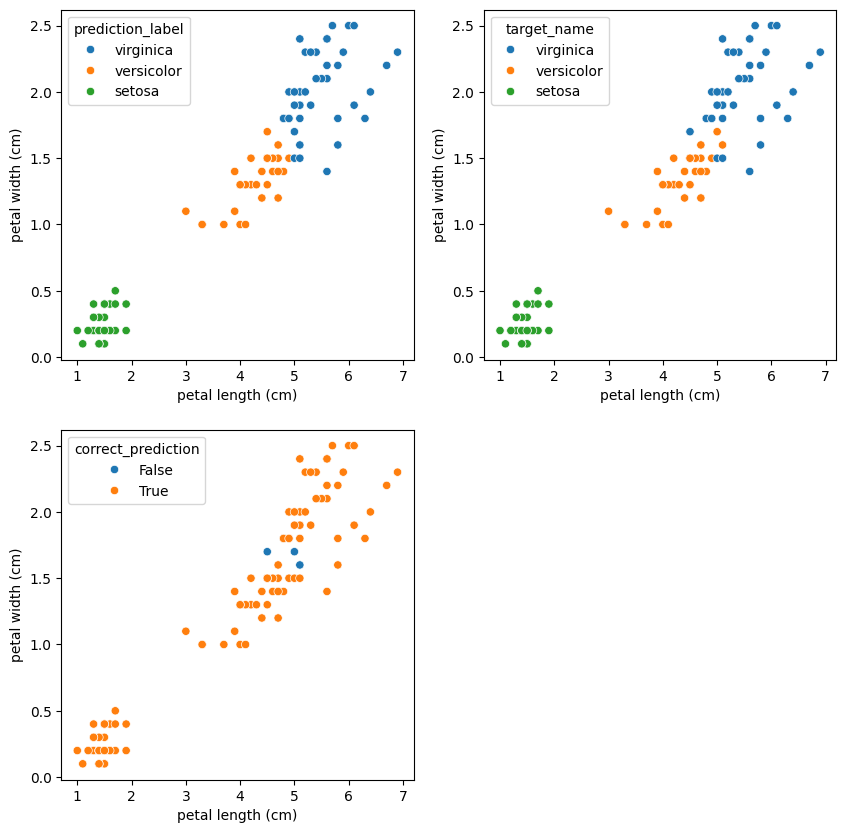

In [43]:
plot_incorrect_predictions(df_predictions, "petal length (cm)", "petal width (cm)")